In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf,pacf, adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from time import time
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler

In [2]:
data=pd.read_csv("SeoulBikeData.csv")
data.head(10)

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,Winter,No Holiday,Yes
5,01/12/2017,100,5,-6.4,37,1.5,2000,-18.7,0.00,0.0,0.0,Winter,No Holiday,Yes
6,01/12/2017,181,6,-6.6,35,1.3,2000,-19.5,0.00,0.0,0.0,Winter,No Holiday,Yes
7,01/12/2017,460,7,-7.4,38,0.9,2000,-19.3,0.00,0.0,0.0,Winter,No Holiday,Yes
8,01/12/2017,930,8,-7.6,37,1.1,2000,-19.8,0.01,0.0,0.0,Winter,No Holiday,Yes
9,01/12/2017,490,9,-6.5,27,0.5,1928,-22.4,0.23,0.0,0.0,Winter,No Holiday,Yes


## Data Preprocessing

In [3]:
data.dtypes

,0
Date,object
Rented Bike Count,int64
Hour,int64
Temperature(C),float64
Humidity(%),int64
Wind speed (m/s),float64
Visibility (10m),int64
Dew point temperature(C),float64
Solar Radiation (MJ/m2),float64
Rainfall(mm),float64


In [4]:
data.isna().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


In [5]:
data.describe()

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [6]:
data["Date"]=pd.to_datetime(data["Date"],format="%d/%m/%Y")
data["Date"]=data["Date"]+pd.to_timedelta(data["Hour"],unit="h")
data=data.set_index(data["Date"])
categorical_cols=["Seasons","Holiday","Functioning Day"]
data[categorical_cols]=data[categorical_cols].astype("category")
for col in categorical_cols:
  print("Column: "+ col+": "+str(data[col].unique()))

data=pd.get_dummies(data,columns=["Seasons"],dtype=int)
holiday_map={"Holiday":0,"No Holiday":1}
functioning_day_map={"Yes":1,"No":0}
data["Holiday"]=data["Holiday"].map(holiday_map)
data["Functioning Day"]=data["Functioning Day"].map(functioning_day_map)

columns_renamed={"Rented Bike Count":"target","Temperature(C)":"temp","Humidity(%)":"hum","Wind speed (m/s)":"wind","Visibility (10m)":"vis",
                 "Dew point temperature(C)":"dew","Solar Radiation (MJ/m2)":"solar","Rainfall(mm)":"rain","Snowfall (cm)":"snow","Holiday":"holiday",
                 "Functioning Day":"func","Seasons_Autumn":"s_autumn","Seasons_Spring":"s_spring","Seasons_Summer":"s_summer","Seasons_Winter":"s_winter"}
data=data.rename(columns=columns_renamed)
data=data[[columns_renamed[old_column_name] for old_column_name in columns_renamed.keys()]]
data.dtypes

Column: Seasons: ['Winter', 'Spring', 'Summer', 'Autumn']
Categories (4, object): ['Autumn', 'Spring', 'Summer', 'Winter']
Column: Holiday: ['No Holiday', 'Holiday']
Categories (2, object): ['Holiday', 'No Holiday']
Column: Functioning Day: ['Yes', 'No']
Categories (2, object): ['No', 'Yes']


,0
target,int64
temp,float64
hum,int64
wind,float64
vis,int64
dew,float64
solar,float64
rain,float64
snow,float64
holiday,category


In [7]:
data.head()

,target,temp,hum,wind,vis,dew,solar,rain,snow,holiday,func,s_autumn,s_spring,s_summer,s_winter
Date,,,,,,,,,,,,,,,
2017-12-01 00:00:00,254,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,1,0,0,0,1
2017-12-01 01:00:00,204,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,1,0,0,0,1
2017-12-01 02:00:00,173,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,1,0,0,0,1
2017-12-01 03:00:00,107,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,1,0,0,0,1
2017-12-01 04:00:00,78,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,1,0,0,0,1


In [8]:
print("Min Date: "+str(data.index.min()))
print("Max Date: "+str(data.index.max()))

Min Date: 2017-12-01 00:00:00
Max Date: 2018-11-30 23:00:00


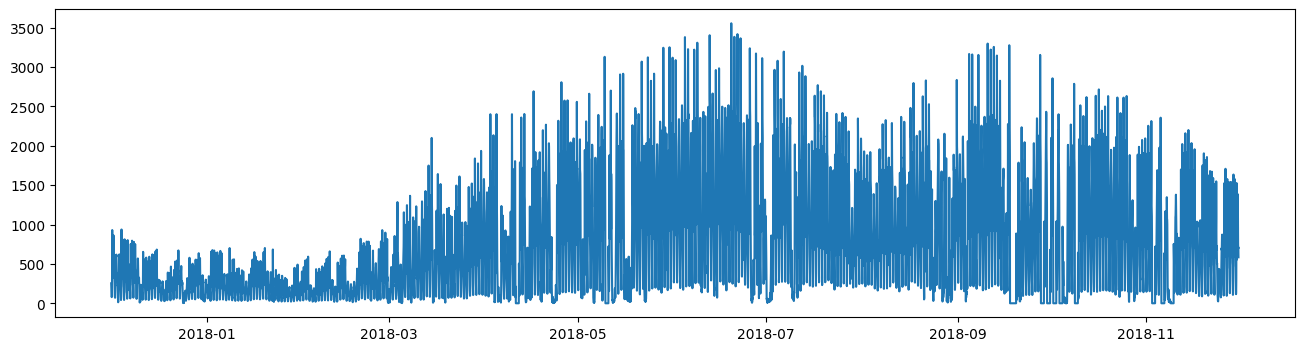

In [9]:
plt.figure(figsize=(16,4))
plt.plot(data["target"])

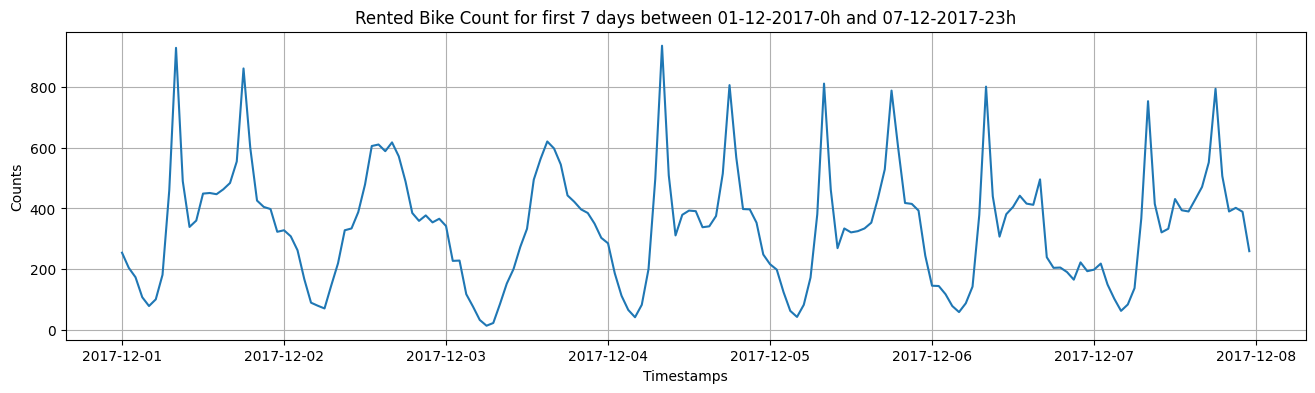

In [10]:
plt.figure(figsize=(16,4))
plt.plot(data["target"][:7*24])
plt.title("Rented Bike Count for first 7 days between 01-12-2017-0h and 07-12-2017-23h")
plt.xlabel("Timestamps")
plt.ylabel("Counts")
plt.grid(True)

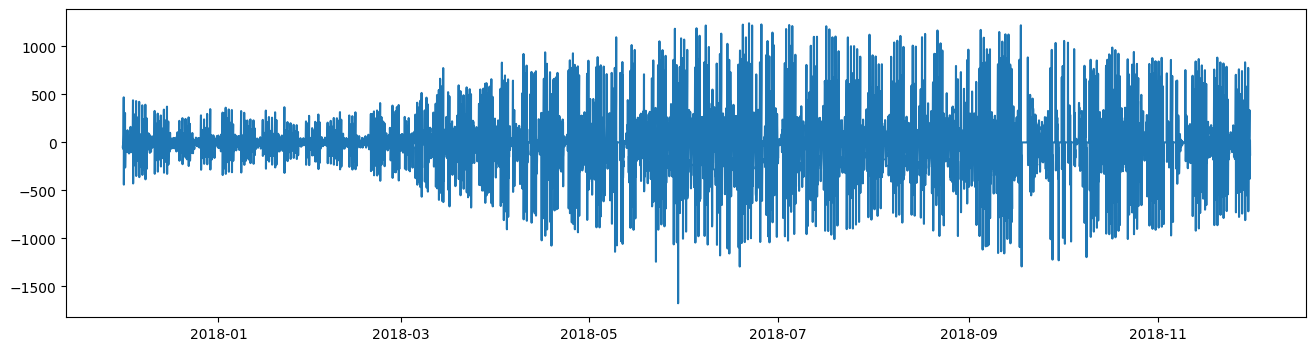

In [11]:
data["first_diff"]=data["target"].diff()
plt.figure(figsize=(16,4))
plt.plot(data["first_diff"][1:])

In [12]:
adf_test=adfuller(data["first_diff"][1:])
print(f'ADF Statistic: {adf_test[0]}')
print(f'p-value: {adf_test[1]}')
print(f'Critical Values: {adf_test[4]}')

ADF Statistic: -22.061339014760847
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4311000545606776), '5%': np.float64(-2.861871474145309), '10%': np.float64(-2.566946438722175)}


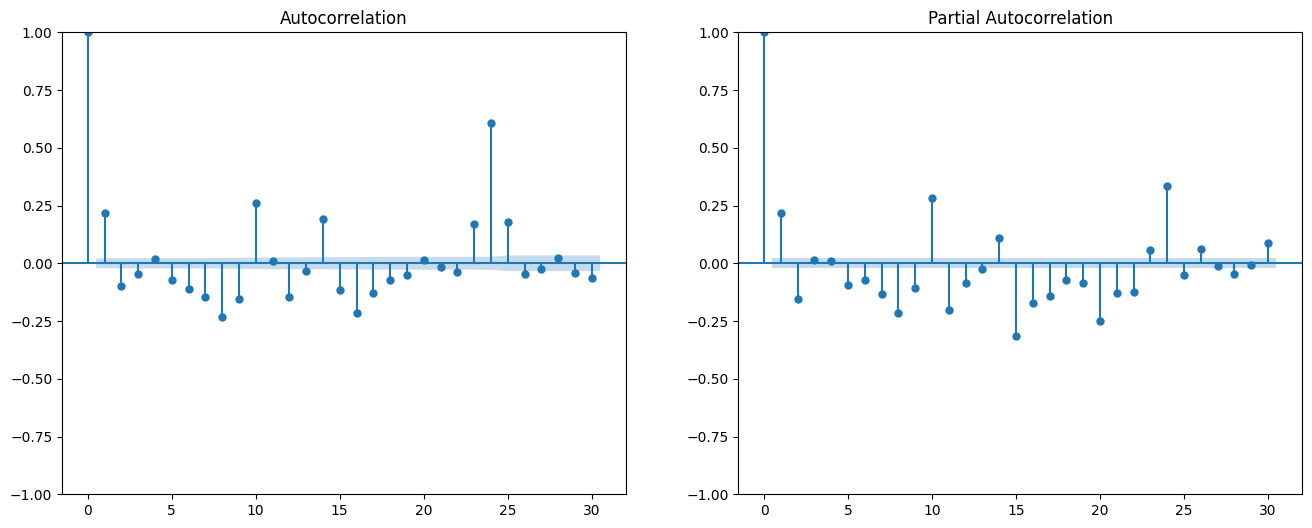

In [13]:
fig, ax=plt.subplots(1,2,figsize=(16,6))
plot_acf(data["first_diff"][1:],lags=30,ax=ax[0])
plot_pacf(data["first_diff"][1:],lags=30,ax=ax[1])
plt.show()

In [14]:
train_data=data.iloc[1:data.shape[0]-24]
test_data=data.iloc[-24:]
print(train_data.shape)
print(test_data.shape)

(8735, 16)
(24, 16)


## Include Regression Terms

In [15]:
scaling_columns=['temp','hum','wind','vis','dew','solar','rain','snow']
scaler=MinMaxScaler()
train_data[scaling_columns]=scaler.fit_transform(train_data[scaling_columns])
test_data[scaling_columns]=scaler.transform(test_data[scaling_columns])
train_data.head()

/tmp/ipykernel_123461/3800067766.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[scaling_columns]=scaler.fit_transform(train_data[scaling_columns])
/tmp/ipykernel_123461/3800067766.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data[scaling_columns]=scaler.transform(test_data[scaling_columns])


,target,temp,hum,wind,vis,dew,solar,rain,snow,holiday,func,s_autumn,s_spring,s_summer,s_winter,first_diff
Date,,,,,,,,,,,,,,,,
2017-12-01 01:00:00,204,0.215035,0.387755,0.108108,1.0,0.224913,0.0,0.0,0.0,1,1,0,0,0,1,-50.0
2017-12-01 02:00:00,173,0.206294,0.397959,0.135135,1.0,0.223183,0.0,0.0,0.0,1,1,0,0,0,1,-31.0
2017-12-01 03:00:00,107,0.202797,0.408163,0.121622,1.0,0.224913,0.0,0.0,0.0,1,1,0,0,0,1,-66.0
2017-12-01 04:00:00,78,0.206294,0.367347,0.310811,1.0,0.207612,0.0,0.0,0.0,1,1,0,0,0,1,-29.0
2017-12-01 05:00:00,100,0.199301,0.377551,0.202703,1.0,0.205882,0.0,0.0,0.0,1,1,0,0,0,1,22.0


In [16]:
exog_columns=scaling_columns+['holiday','func','s_autumn','s_spring','s_summer','s_winter']

In [17]:
# non_seasonal_orders=(0,1,0)
non_seasonal_orders=(2,0,3)
seasonal_orders=(1,0,1,24)

In [18]:
ts_model_sarimax=SARIMAX(train_data["first_diff"],order=non_seasonal_orders,seasonal_order=seasonal_orders,exog=train_data[exog_columns],enforce_stationarity=False)
start=time()
model_fit_sarimax=ts_model_sarimax.fit()
end=time()
print("Model Fitting Time: ", end-start)
print(model_fit_sarimax.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model Fitting Time:  182.43042874336243
                                      SARIMAX Results                                       
Dep. Variable:                           first_diff   No. Observations:                 8735
Model:             SARIMAX(2, 0, 3)x(1, 0, [1], 24)   Log Likelihood              -58378.583
Date:                              Thu, 30 Apr 2026   AIC                         116801.166
Time:                                      11:25:56   BIC                         116956.747
Sample:                                  12-01-2017   HQIC                        116854.193
                                       - 11-29-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp         317.0813    121.428      2.611      0.009    

In [19]:
predictions_sarimax=model_fit_sarimax.forecast(len(test_data),exog=test_data[exog_columns])
predictions_sarimax=pd.Series(predictions_sarimax,index=test_data.index)
residuals_sarimax=test_data["first_diff"]-predictions_sarimax

Text(0.5, 1.0, 'Residuals Plot')

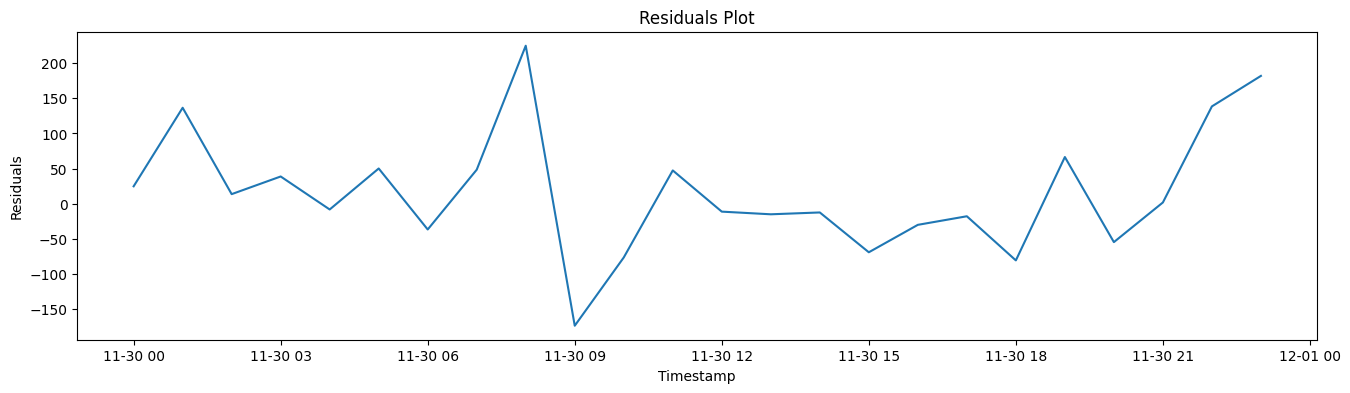

In [20]:
plt.figure(figsize=(16,4))
plt.plot(residuals_sarimax)
plt.ylabel("Residuals")
plt.xlabel("Timestamp")
plt.title("Residuals Plot")

Text(0, 0.5, 'First Differences')

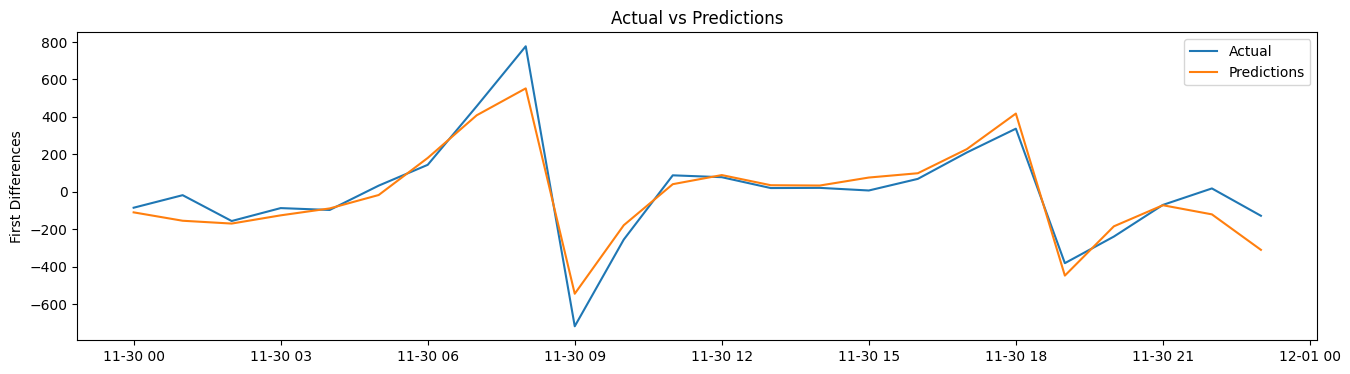

In [21]:
plt.figure(figsize=(16,4))
plt.plot(test_data["first_diff"])
plt.plot(predictions_sarimax)
plt.legend(('Actual','Predictions'))
plt.title('Actual vs Predictions')
plt.ylabel('First Differences')

In [22]:
print('Mean Absolute Percent Error:', round(np.mean(abs(residuals_sarimax/test_data["first_diff"])),4))
print('Root Mean Squared Error:', np.sqrt(np.mean(residuals_sarimax**2)))

Mean Absolute Percent Error: 1.3923
Root Mean Squared Error: 88.66886131955735


## When all the exog variables were used to predict using rolling forecast origin, the metrics were:

Mean Absolute Percent Error(MAPE): 1.2026  
Root Mean Squared Error(RMSE): 119.05283239160617

## Refit model with updated parameters

In [26]:
# removed_columns=['snow','s_summer','s_winter','s_spring','holiday','s_autumn','solar','wind','dew']
removed_columns=['snow','holiday','wind','rain','vis']
exog_columns_subset=[col for col in exog_columns if col not in removed_columns]
ts_model_sarimax_subset=SARIMAX(train_data["first_diff"],order=non_seasonal_orders,seasonal_order=seasonal_orders,exog=train_data[exog_columns_subset])
start=time()
model_fit_sarimax_subset=ts_model_sarimax_subset.fit()
end=time()
print("Model Fitting Time: ", end-start)
print(model_fit_sarimax_subset.summary())

predictions_sarimax_subset=model_fit_sarimax_subset.forecast(len(test_data),exog=test_data[exog_columns_subset])
predictions_sarimax_subset=pd.Series(predictions_sarimax_subset,index=test_data.index)
residuals_sarimax_subset=test_data["first_diff"]-predictions_sarimax_subset

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Model Fitting Time:  304.32977986335754
                                      SARIMAX Results                                       
Dep. Variable:                           first_diff   No. Observations:                 8735
Model:             SARIMAX(2, 0, 3)x(1, 0, [1], 24)   Log Likelihood              -58536.202
Date:                              Thu, 30 Apr 2026   AIC                         117106.403
Time:                                      11:37:54   BIC                         117226.680
Sample:                                  12-01-2017   HQIC                        117147.391
                                       - 11-29-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp         325.6060    106.764      3.050      0.002    

In [24]:
print('Mean Absolute Percent Error:', round(np.mean(abs(residuals_sarimax_subset/test_data['first_diff'])),4))
print('Root Mean Squared Error:', np.sqrt(np.mean(residuals_sarimax_subset**2)))

Mean Absolute Percent Error: 1.0923
Root Mean Squared Error: 80.79364626217615


In [28]:
train_data_rolling=train_data.copy()
rolling_preds=[]
start=time()
for row in test_data.index:
  print(train_data_rolling.shape)
  print(row)
  model_rolling=SARIMAX(train_data_rolling["first_diff"],order=non_seasonal_orders,seasonal_order=seasonal_orders,exog=train_data_rolling[exog_columns_subset],enforce_stationarity=False)
  model_rolling_fit=model_rolling.fit()

  pred=model_rolling_fit.forecast(exog=test_data.loc[row,exog_columns_subset])
  rolling_preds.append(pred.values[0])
  train_data_rolling=pd.concat([train_data_rolling,test_data.loc[[row]]])
end=time()
print("Time took to run: ", end-start)

(8735, 16)
2018-11-30 00:00:00


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(8736, 16)
2018-11-30 01:00:00


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(8737, 16)
2018-11-30 02:00:00


...

(8757, 16)
2018-11-30 22:00:00


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(8758, 16)
2018-11-30 23:00:00


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Time took to run:  3464.7003843784332


In [29]:
result=pd.DataFrame(data={'actual':test_data['first_diff'],'rolling_preds':rolling_preds,'rolling_residuals':test_data['first_diff']-rolling_preds},index=test_data.index)
print('Mean Absolute Percent Error:', round(np.mean(abs(result['rolling_residuals']/result['actual'])),4))
print('Root Mean Squared Error:', np.sqrt(np.mean(result['rolling_residuals']**2)))

Mean Absolute Percent Error: 1.2101
Root Mean Squared Error: 77.21401684149701


Text(0.5, 1.0, 'Rolling Residuals Plot')

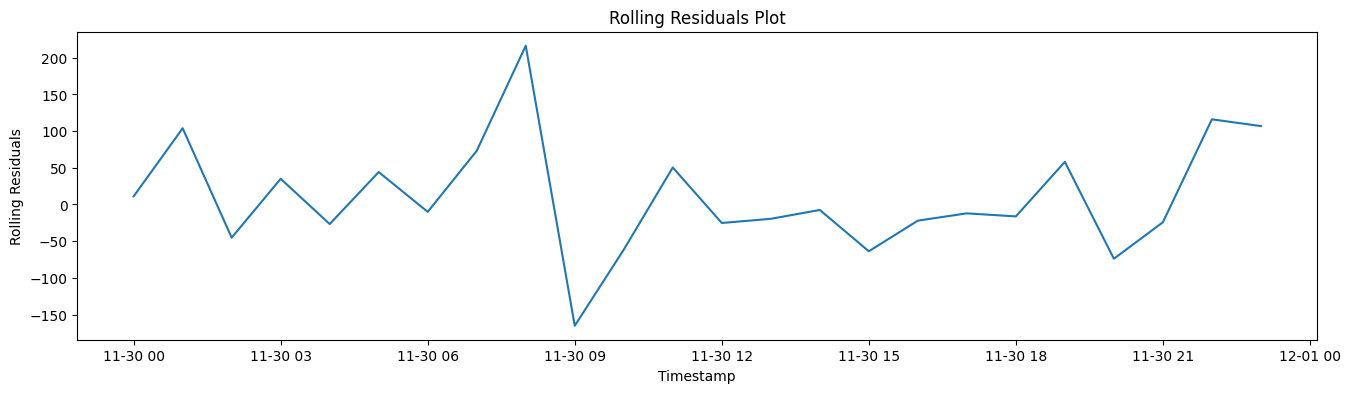

In [30]:
plt.figure(figsize=(16,4))
plt.plot(result['rolling_residuals'])
plt.ylabel("Rolling Residuals")
plt.xlabel("Timestamp")
plt.title("Rolling Residuals Plot")

Text(0, 0.5, 'First Differences')

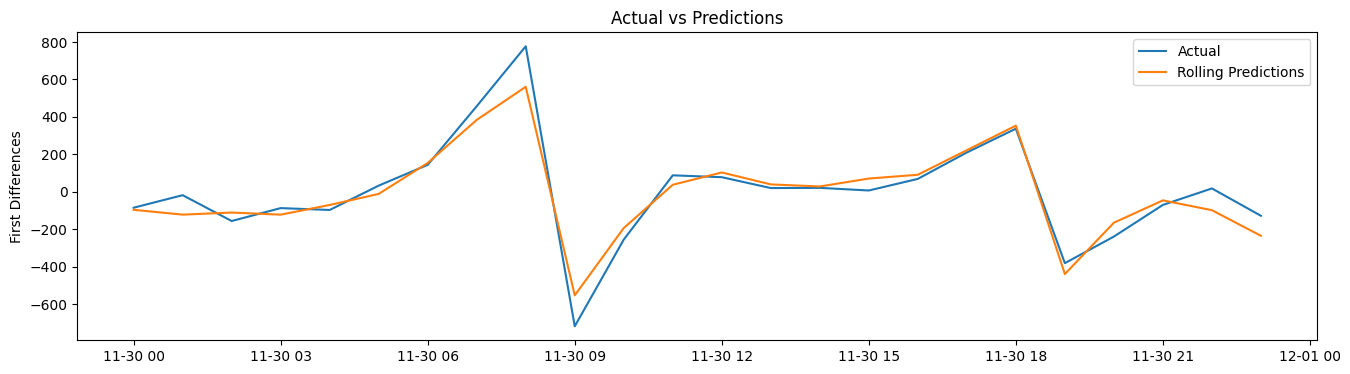

In [31]:
plt.figure(figsize=(16,4))
plt.plot(result["actual"])
plt.plot(result['rolling_preds'])
plt.legend(('Actual','Rolling Predictions'))
plt.title('Actual vs Predictions')
plt.ylabel('First Differences')

Text(0, 0.5, 'Residuals')

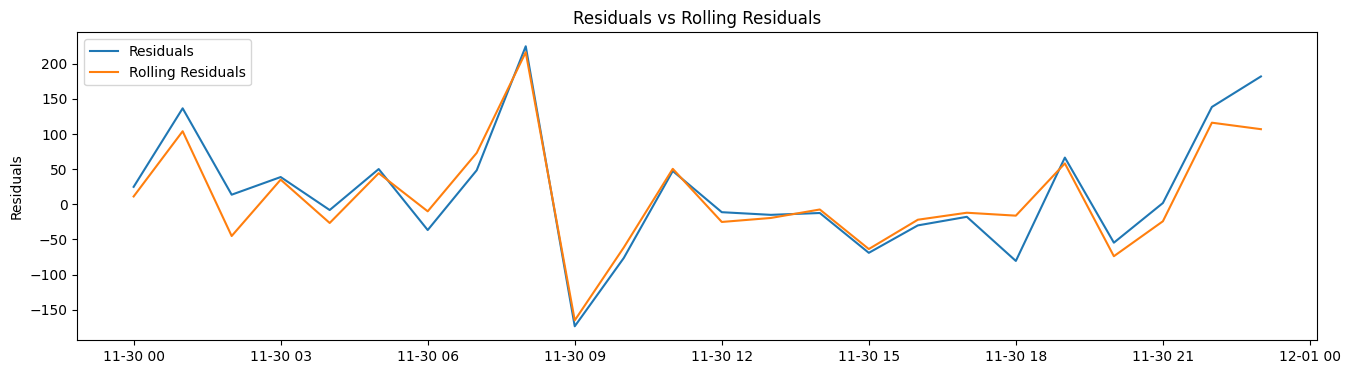

In [32]:
plt.figure(figsize=(16,4))
plt.plot(residuals_sarimax)
plt.plot(result['rolling_residuals'])
plt.legend(('Residuals','Rolling Residuals'))
plt.title('Residuals vs Rolling Residuals')
plt.ylabel('Residuals')

In [33]:
test_data_copy=test_data.copy()
empty_row=pd.DataFrame([[np.nan]*len(test_data.columns)],columns=test_data.columns)
test_data_copy=pd.concat([empty_row,test_data_copy])
test_data_copy.iloc[0,0]=train_data.iloc[train_data.shape[0]-1,0]

/tmp/ipykernel_123461/1362157325.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  test_data_copy=pd.concat([empty_row,test_data_copy])
/tmp/ipykernel_123461/1362157325.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  test_data_copy=pd.concat([empty_row,test_data_copy])


In [34]:
print(result['rolling_residuals'][:5])

Date
2018-11-30 00:00:00     11.074181
2018-11-30 01:00:00    103.887432
2018-11-30 02:00:00    -45.217135
2018-11-30 03:00:00     35.004151
2018-11-30 04:00:00    -26.665611
Name: rolling_residuals, dtype: float64


In [35]:
# # print(test_data_copy.head())
# test_data_copy["first_diff_preds"]=result['rolling_residuals']
# test_data_copy["first_diff_preds"]=test_data_copy["first_diff_preds"].shift(-1)
# # print(test_data_copy.head())
# test_data_copy["target_preds"]=test_data_copy["target"]+test_data_copy["first_diff_preds"]
# # print(test_data_copy.head())
# test_data_copy["target_preds"]=test_data_copy["target_preds"].shift(1)
# # print(test_data_copy.head())
# test_data_copy=test_data_copy.iloc[1:]

In [36]:
last_target_val_train=test_data_copy.iloc[0,0]
test_data_copy["first_diff_preds"]=result['rolling_residuals']
test_data_copy["cumulative_diffs"]=np.cumsum(result['rolling_residuals'])
test_data_copy["target_preds"]=test_data_copy["cumulative_diffs"]+last_target_val_train
test_data_copy=test_data_copy.iloc[1:]

In [37]:
test_data_copy[["target","target_preds","first_diff","first_diff_preds","cumulative_diffs"]]

,target,target_preds,first_diff,first_diff_preds,cumulative_diffs
2018-11-30 00:00:00,474.0,570.074181,-85.0,11.074181,11.074181
2018-11-30 01:00:00,456.0,673.961613,-18.0,103.887432,114.961613
2018-11-30 02:00:00,300.0,628.744477,-156.0,-45.217135,69.744477
2018-11-30 03:00:00,213.0,663.748629,-87.0,35.004151,104.748629
2018-11-30 04:00:00,116.0,637.083017,-97.0,-26.665611,78.083017
2018-11-30 05:00:00,149.0,681.267683,33.0,44.184666,122.267683
2018-11-30 06:00:00,293.0,671.198034,144.0,-10.069649,112.198034
2018-11-30 07:00:00,750.0,744.306345,457.0,73.108311,185.306345
2018-11-30 08:00:00,1527.0,960.664427,777.0,216.358083,401.664427
2018-11-30 09:00:00,809.0,795.430700,-718.0,-165.233727,236.430700


Text(0, 0.5, 'Values')

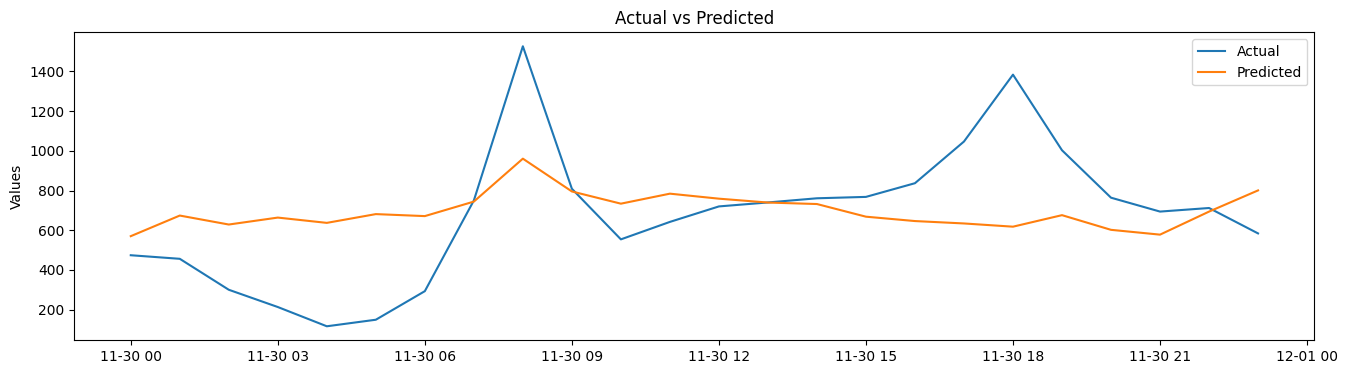

In [38]:
plt.figure(figsize=(16,4))
plt.plot(test_data_copy.loc[:,"target"])
plt.plot(test_data_copy.loc[:,'target_preds'])
plt.legend(('Actual','Predicted'))
plt.title('Actual vs Predicted')
plt.ylabel('Values')

In [40]:
model_fit_sarimax_subset.save("bike_sharing_ts_model_sarimax.pkl")